# Ideal NMPC on the IDAES CSTR

The closed loop the declarations describe, in one call: at each step
`drto.ideal_nmpc` solves the horizon at the measured state, implements
the first move on the process, and simulates the process one sample
forward. Ideal means the solve is treated as instantaneous, the
baseline the delayed and advanced-step loops are judged against. The
call builds both sides itself: the input model becomes the controller,
a clone becomes the plant, and the cold start, the warm start, and
the persistent scaled clones are the earlier features run in their
documented order.

## The declared model and its setpoint

The saponification CSTR of `models/idaes_cstr.py`, as IDAES wrote it.
The setpoint comes from the steady reduction at zero duty and nominal
feed; the start is hot (318 K) with the conversion knocked back. The
setup wraps in a function so the noisy run at the end can rebuild it. The
setup wraps in a function so the noisy variant at the end can rebuild
it. The
infinite-horizon transform and the units-driven scaling tags are part
of defining the model; the loop takes it from there.

In [1]:
import pyomo.environ as pyo

import drto
from models.idaes_cstr import DC_START, F_IN, VOLUME, build, scaled_solve, tag_scaling


def setup(disturbance=False):
    m = build(disturbance=disturbance)
    ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
        m, controls={m.fs.cstr.control_volume.heat.name: 0.0,
                     m.fs.cstr.inlet.flow_vol.name: F_IN})
    scaled_solve(ss)
    cvs = ss.fs.cstr.control_volume
    for j, ssp in (("NaOH", m.ss_naoh), ("EthylAcetate", m.ss_ea),
                   ("SodiumAcetate", m.ss_sa), ("Ethanol", m.ss_etoh)):
        ssp.set_value(pyo.value(cvs.material_holdup["Liq", j]))
    for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
                   ("SodiumAcetate", -1), ("Ethanol", -1)):
        m.mat0[j] = pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
    for k in m.eng_ss:
        m.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
    pyo.TransformationFactory("drto.infinite_horizon").apply_to(m)
    tag_scaling(m)
    return m


m = setup()

## The loop, one call

Ten samples of closed loop. Inside the call: the process clone in
simulation mode at the declared targets, the dynamic optimization
assembly, an exponential cold start (time constant 0.3 s) for the
first solves on both sides, and every re-solve warm-started from the
previous solution shifted one sample, the warm start options applied
at the call site (a `warm_start` mapping retunes them). The scaling
tags put the whole loop on one persistent scaled clone per side; the
history reads back in physical units.

In [2]:
import time

tic = time.time()
history = drto.ideal_nmpc(
    m,
    steps=10,
    cold_start={"profile": "exponential", "time_constant": 0.3},
    solver="ipopt",
)
print(history)
print(f"{time.time() - tic:.0f} s for 10 steps, a controller and a plant solve each")

drto nmpc history: 10 steps, states material_holdup_Liq_NaOH, material_holdup_Liq_EthylAcetate, material_holdup_Liq_SodiumAcetate, material_holdup_Liq_Ethanol, energy_holdup[Liq]; moves heat, _flow_vol_inlet_ref
6 s for 10 steps, a controller and a plant solve each


## The actual trajectories

With a perfect model and no noise the ideal loop rides its own plan:
the holdups run from the knocked-back start onto their setpoints, the
energy comes down from the hot start, and the moves settle onto the
declared targets, each held over its sample.

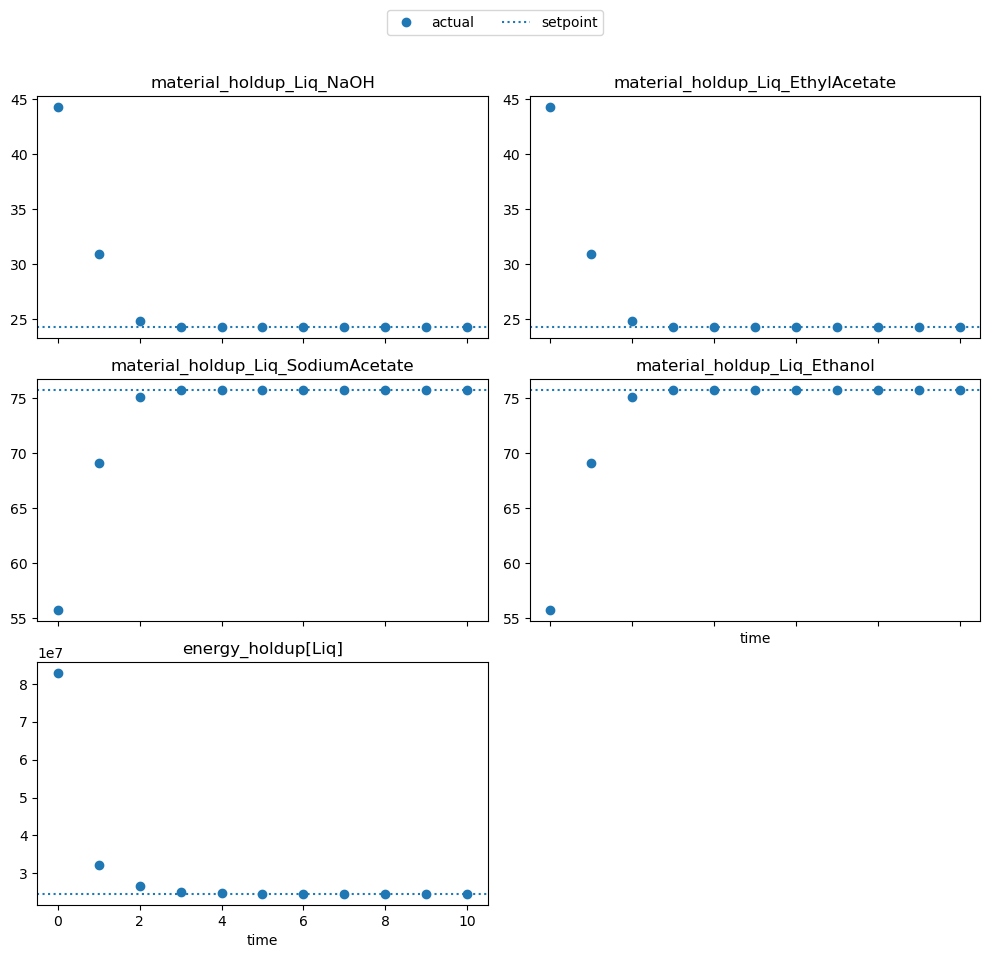

In [3]:
axes = drto.plot_states(history)

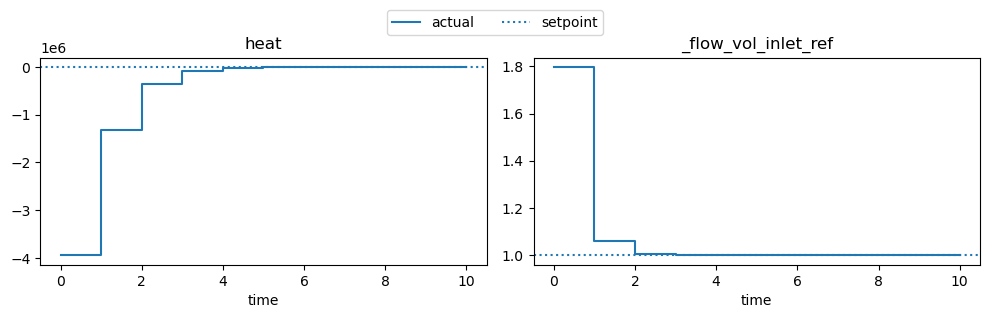

In [4]:
axes = drto.plot_controls(history)

## The same loop under process noise

Rebuilt with `disturbance=True`, every state's balance carries its own
additive noise term: mol/s in each species holdup equation, W in the
energy equation, zero nominally, written into the IDAES-generated
balances through the control volume's custom terms. The loop draws
each step's realization normally, zero mean with the given standard
deviation per term, reproducible under `seed`. The plant feels the
draws, the controller plans without them, and the holdups settle into
a band around their setpoints instead of onto them, the moves working
against each draw.

In [5]:
noisy = drto.ideal_nmpc(
    setup(disturbance=True),
    steps=10,
    disturbances={"w_NaOH": 0.5, "w_EthylAcetate": 0.5,
                  "w_SodiumAcetate": 0.5, "w_Ethanol": 0.5,
                  "w_energy": 2e5},
    seed=7,
    cold_start={"profile": "exponential", "time_constant": 0.3},
    solver="ipopt",
)
print(noisy)
print("w_NaOH draws:", " ".join(f"{w:+.2f}" for w in noisy.realizations["w_NaOH"]))

drto nmpc history: 10 steps, states material_holdup_Liq_NaOH, material_holdup_Liq_EthylAcetate, material_holdup_Liq_SodiumAcetate, material_holdup_Liq_Ethanol, energy_holdup[Liq]; moves heat, _flow_vol_inlet_ref
w_NaOH draws: -0.13 -0.11 +0.20 +0.25 +0.15 +0.20 -0.31 +0.12 -0.40 +0.65


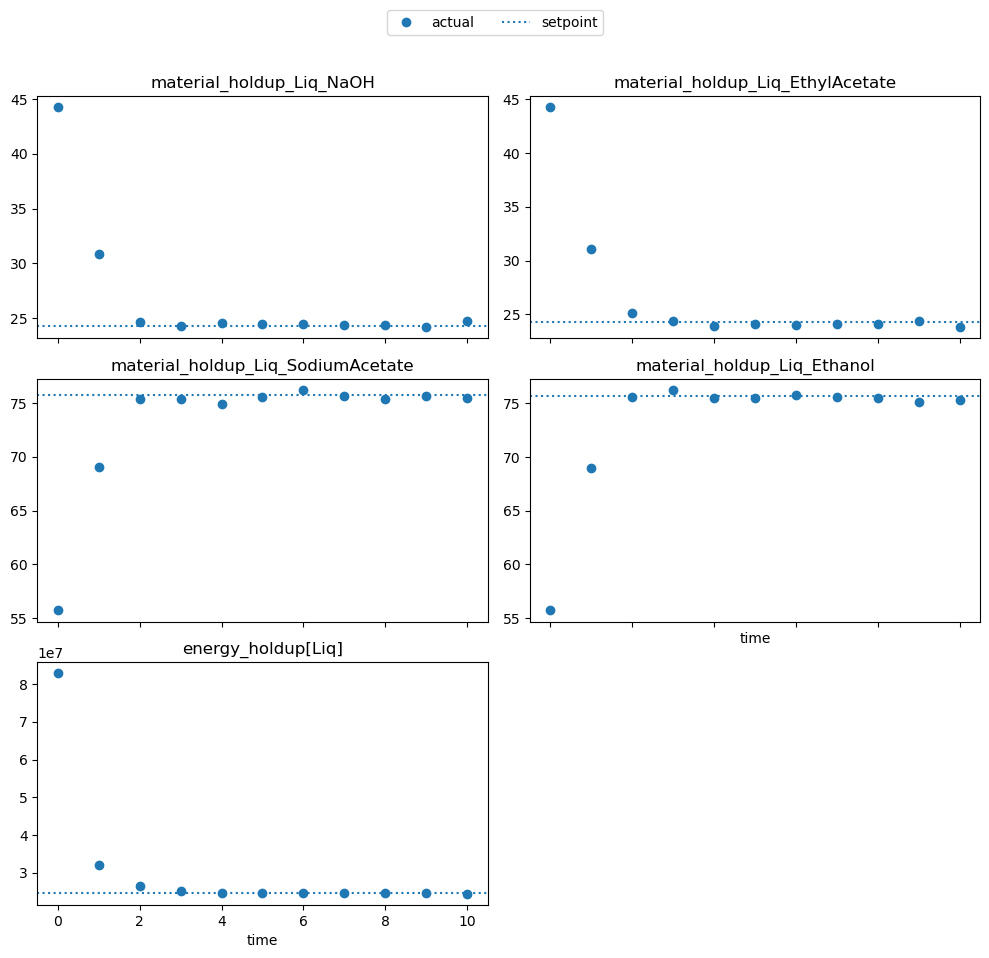

In [6]:
axes = drto.plot_states(noisy)

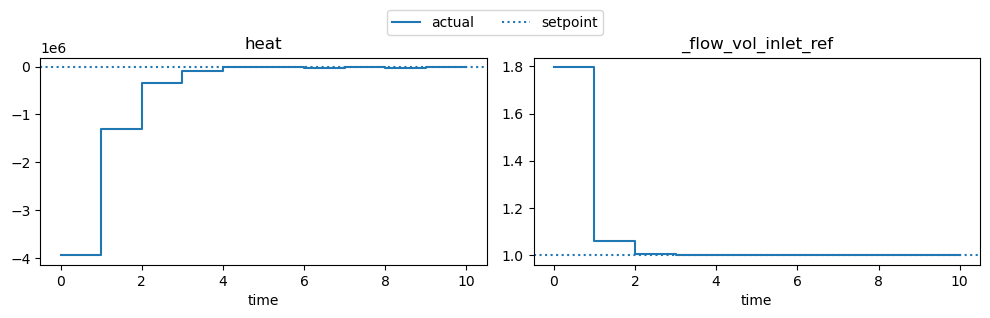

In [7]:
axes = drto.plot_controls(noisy)